[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vicradon/ml-workspace/blob/main/shape_detection/notebook.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/vicradon/ml-workspace/blob/main/shape_detection/notebook.ipynb)

In [14]:
IMAGE_DIMENSION=200

import os
os.environ["IMAGE_DIMENSION"] = str(IMAGE_DIMENSION)

In [15]:
%%bash
wget -qO shapegen https://github.com/vicradon/shapegen/releases/download/v0.0.1/shapegen-linux-amd64
cd /kaggle/working
chmod +x shapegen
./shapegen -size $IMAGE_DIMENSION
unzip -qo shape_dataset_coco.zip


  ╔═══════════════════════════════════════╗
  ║    Shape Dataset Generator  v1.0      ║
  ╚═══════════════════════════════════════╝

  Classes  : 7  (triangle, quadrilateral, pentagon, hexagon, heptagon, octagon, decagon)
  Images   : 100 per class  (700 total)
  Size     : 200x200 px
  Format   : COCO
  Workers  : 4
  Output   : shape_dataset_coco.zip

  Generating images…
  done [████████████████████████████████████████] 100%  700/700%  700/700
  ✓ Generated 700 images in 1.5s

  Packing COCO ZIP…
  ✓ ZIP written in 147ms  (2.5 MB)

  ┌─────────────────────────────────────┐
  │  Output → shape_dataset_coco.zip    │
  └─────────────────────────────────────┘



In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

In [17]:
import json
from itertools import islice

with open("/kaggle/working/annotations/instances.json", "r") as annotation_data:
    content = annotation_data.read()
    
annotation_data = json.loads(content)

categories = pd.DataFrame(annotation_data["categories"])
images = pd.DataFrame(annotation_data["images"])
annotations = pd.DataFrame(annotation_data["annotations"])

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np

img_to_label = annotations.groupby("image_id")["category_id"].first()
images["label"] = images["id"].map(img_to_label)

label_map = {cat_id: i for i, cat_id in enumerate(sorted(images["label"].unique()))}
images["label"] = images["label"].map(label_map)

class ShapeDataset(Dataset):
    def __init__(self, df, root_dir):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["file_name"])
        image = Image.open(img_path).convert("L")
        image = torch.tensor(np.array(image), dtype=torch.float32) / 255.0
        image = image.unsqueeze(0)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label

dataset = ShapeDataset(images, "/kaggle/working")

train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)


In [19]:
categories

,id,name,supercategory
0,1,triangle,shape
1,2,quadrilateral,shape
2,3,pentagon,shape
3,4,hexagon,shape
4,5,heptagon,shape
5,6,octagon,shape
6,7,decagon,shape


In [20]:
images.head()

,id,file_name,width,height,label
0,1,images/triangle_0000.png,200,200,0
1,2,images/triangle_0001.png,200,200,0
2,3,images/triangle_0002.png,200,200,0
3,4,images/triangle_0003.png,200,200,0
4,5,images/triangle_0004.png,200,200,0


In [21]:
annotations.head()

,id,image_id,category_id,bbox,area,iscrowd
0,1,1,1,"[64.27, 51.09, 80.29, 80.88]",6493.79,0
1,2,2,1,"[43.4, 66.27, 111.34, 102.79]",11444.28,0
2,3,3,1,"[44.27, 31.45, 104.17, 93.39]",9728.57,0
3,4,4,1,"[55.21, 50.56, 102.29, 111.12]",11366.65,0
4,5,5,1,"[53.2, 27.3, 89.78, 82.03]",7364.15,0


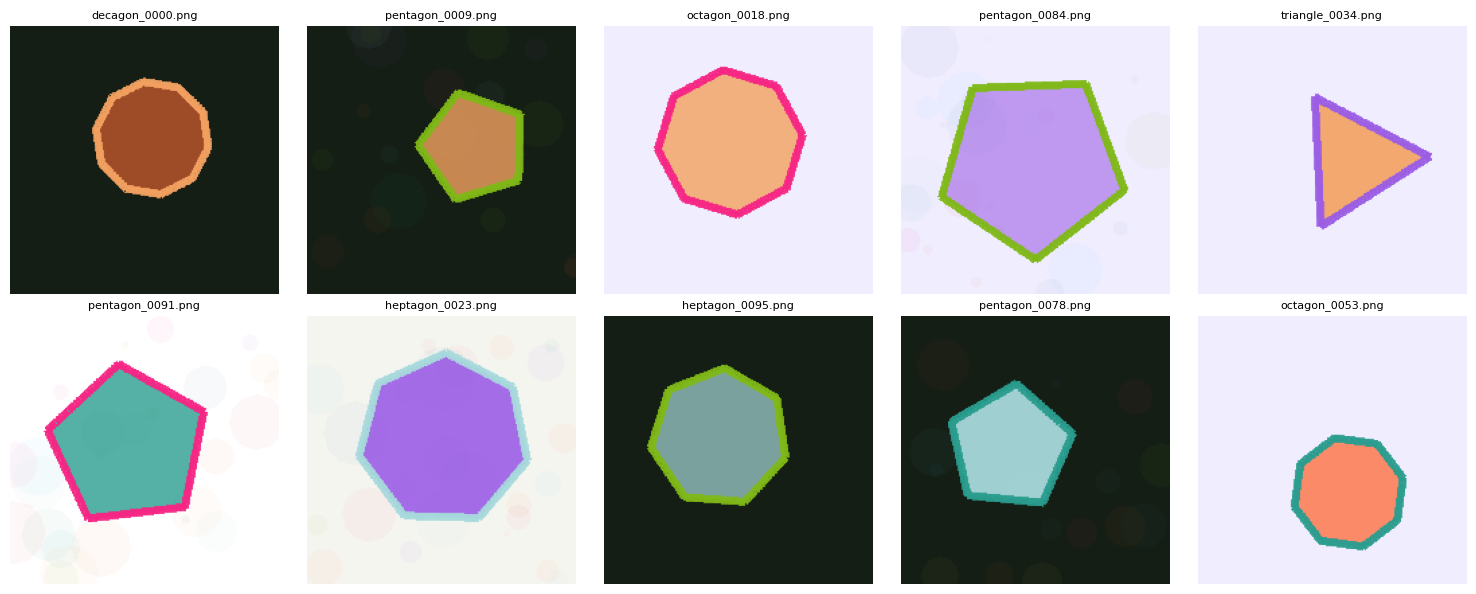

In [22]:
import os
from PIL import Image

first_10 = images.sample(10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (_, row) in enumerate(first_10.iterrows()):
    img = Image.open(row["file_name"])
    axes[i].imshow(img)
    axes[i].set_title(row["file_name"].split("/")[-1], fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [23]:
import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self, image_size, num_classes):
        super().__init__()
        self.image_size = image_size
        self.input_dim = image_size * image_size

        self.model = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), self.input_dim)
        return self.model(x)


network = NeuralNetwork(image_size=IMAGE_DIMENSION, num_classes=10)


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = network.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")


Epoch 1/10 | Loss: 98.1831 | Acc: 0.1457


KeyboardInterrupt: 